# virtual icechunk ingestion Proof of Concept

## Prerequisites:
- [ESGF-Playground](https://github.com/ESGF/ESGF-Playground) needs to be deployed (`docker compose up -d`)

- To wipe and start fresh use 

```bash
docker compose down -v && rm -rf esdata-east esdata-west esdata-secondary && docker compose up -d
```



In [1]:
import httpx

LOCAL_STAC = "http://localhost:9010"
CEDA_STAC  = "https://api.stac.esgf.ceda.ac.uk"
COLLECTION = "CMIP6"

In [2]:
# Health Check for the Playground
try:
    r = httpx.get(LOCAL_STAC, timeout=5)
    r.raise_for_status()
    info = r.json()
    print(f"✓ Playground is up")
    print(f"  title:   {info.get('title', 'n/a')}")
    print(f"  version: {info.get('stac_version', 'n/a')}")
except httpx.ConnectError:
    raise RuntimeError(
        "Cannot reach the playground. "
        "Run: docker compose up -d  (from the ESGF-Playground directory)"
    )
except httpx.TimeoutException:
    raise RuntimeError(
        "Playground is up but not responding yet — stac-fastapi-es needs ~30-60s "
        "after 'docker compose up -d' for Elasticsearch to become ready. Wait and retry."
    )

✓ Playground is up
  title:   Simulated ESGF East Node Index STAC interface
  version: 1.0.0


## Mirror a few example entries from the CEDA stac catalog


In [3]:
collection = httpx.get(f"{CEDA_STAC}/collections/{COLLECTION}", timeout=30).json()

# stac-fastapi-es rejects unknown top-level fields
for field in ["assets", "links"]:
    collection.pop(field, None)

r = httpx.post(f"{LOCAL_STAC}/collections", json=collection, timeout=30)

if r.status_code == 409:
    print("Collection already exists — skipping")
elif r.status_code in (200, 201):
    print(f"✓ Collection created: {collection['id']}")
else:
    r.raise_for_status()

HTTPStatusError: Server error '500 Internal Server Error' for url 'http://localhost:9010/collections'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/500

In [6]:
collection = httpx.get(f"{CEDA_STAC}/collections/", timeout=30).json()

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [5]:
r = httpx.get(f"{CEDA_STAC}/collections/{COLLECTION}/items?limit=50", timeout=30)
r.raise_for_status()
all_items = r.json()["features"]

# Keep only items that already have a reference_file (kerchunk) asset
items_with_ref = [i for i in all_items if "reference_file" in i.get("assets", {})]
print(f"Fetched {len(all_items)} items from CEDA, {len(items_with_ref)} have reference_file")

Fetched 0 items from CEDA, 0 have reference_file


In [34]:
all_items[0]['assets']

{'reference_file': {'alternate:name': 'ceda.ac.uk',
  'file:checksum': '0',
  'open_zarr_kwargs': {'decode_times': True},
  'created': '2025-09-26T12:30:29Z',
  'roles': ['reference', 'data'],
  'description': 'HTTPServer Link',
  'alternate': {'dkrz.de': {'alternate:name': 'dkrz.de',
    'role': ['data'],
    'description': 'DUMMY DKRZ HTTPServer Link.',
    'href': 'https://dkrz.de/badc/cmip6/metadata/kerchunk/pipeline1/VolMIP/NERC/UKESM1-0-LL/kr1.0/CMIP6_VolMIP_NERC_UKESM1-0-LL_volc-pinatubo-full_r9i1p1f2_day_zg_gn_v20230810_kr1.0.json',
    'type': 'application/netcdf'}},
  'type': 'application/zstd',
  'title': None,
  'protocol': 'https',
  'name': 'reference',
  'href': 'https://dap.ceda.ac.uk/badc/cmip6/metadata/kerchunk/pipeline1/VolMIP/NERC/UKESM1-0-LL/kr1.0/CMIP6_VolMIP_NERC_UKESM1-0-LL_volc-pinatubo-full_r9i1p1f2_day_zg_gn_v20230810_kr1.0.json',
  'cmip6:tracking_id': 'hdl:21.14100/4d437ff7-ab9c-43ee-8cc9-7b13a8e0e785',
  'updated': '2025-09-26T12:30:29Z',
  'file:size': 0}

In [27]:
# Prototype the virtualization of one file
# Questions: is 'data' assumed to be the source of truth? Or is there another heuristic?

netcdf_urls = {
    item['id']:{aid:a['href'] for aid, a in item['assets'].items() if 'reference' not in a['roles']} for item in items_with_ref  
}

netcdf_urls

{'CMIP6.VolMIP.NERC.UKESM1-0-LL.volc-pinatubo-full.r9i1p1f2.day.zg.gn.v20230810': {'data0001': 'https://dap.ceda.ac.uk/badc/cmip6/data/CMIP6/VolMIP/NERC/UKESM1-0-LL/volc-pinatubo-full/r9i1p1f2/day/zg/gn/v20230810/zg_day_UKESM1-0-LL_volc-pinatubo-full_r9i1p1f2_gn_19910601-19940630.nc'},
 'CMIP6.VolMIP.NERC.UKESM1-0-LL.volc-pinatubo-full.r9i1p1f2.day.wap.gn.v20230810': {'data0001': 'https://dap.ceda.ac.uk/badc/cmip6/data/CMIP6/VolMIP/NERC/UKESM1-0-LL/volc-pinatubo-full/r9i1p1f2/day/wap/gn/v20230810/wap_day_UKESM1-0-LL_volc-pinatubo-full_r9i1p1f2_gn_19910601-19940630.nc'},
 'CMIP6.VolMIP.NERC.UKESM1-0-LL.volc-pinatubo-full.r9i1p1f2.day.uas.gn.v20230810': {'data0001': 'https://dap.ceda.ac.uk/badc/cmip6/data/CMIP6/VolMIP/NERC/UKESM1-0-LL/volc-pinatubo-full/r9i1p1f2/day/uas/gn/v20230810/uas_day_UKESM1-0-LL_volc-pinatubo-full_r9i1p1f2_gn_19910601-19940630.nc'},
 'CMIP6.VolMIP.NERC.UKESM1-0-LL.volc-pinatubo-full.r9i1p1f2.day.ta.gn.v20230810': {'data0001': 'https://dap.ceda.ac.uk/badc/cmip6/dat

In [30]:
# now virtualize
from obstore.store import from_url
from virtualizarr.registry import ObjectStoreRegistry
from virtualizarr.parsers import HDFParser
from virtualizarr.xarray import open_virtual_mfdataset
import xarray as xr
from typing import List
import icechunk as ic

parser = HDFParser() #TODO, we might need to be more flexible if data is not written in HDF 😩

def virtualize_from_urls(urls:List[str]) -> xr.Dataset:

    # ? Should we actually error out if we detect more than one 'bucket', i.e. http node?
    buckets = set('/'.join(url.split('/')[:3]) for url in urls)# TODO. Proper safe parsing
    #TODO test this with actually multiple files
    registry = ObjectStoreRegistry({bucket: from_url(bucket) for bucket in buckets})

    vds = open_virtual_mfdataset(
        urls=urls,
        parser=parser,
        registry=registry,
        )
    return vds, registry

# def get_data_urls_from_item(item:dict) -> :

for cmip_id, url_dict in netcdf_urls.items():
    urls = url_dict.values()
    vds, registry = virtualize_from_urls(urls)

    storage = ic.local_filesystem_storage(f'temp_test/{cmip_id}')
    config = ic.RepositoryConfig.default()
    # set (possibly multiple, see above) virtual chunk containers
    for k in registry.map.keys():
        url_prefix = f"{k.scheme}://{k.netloc}/"
        config.set_virtual_chunk_container(
            ic.VirtualChunkContainer(
                url_prefix=url_prefix,
                store=ic.http_store(),
            ),
        )
    repo = ic.Repository.open_or_create(storage=storage, config=config)
    session = repo.writable_session('main')
    vds.vz.to_icechunk(session.store)
    snapshot_id = session.commit("cmip")
    repo.save_config()
    print(snapshot_id)
    break


/Users/juliusbusecke/Code/cmip7-virtualization/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:139: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


  2026-04-06T23:36:55.202374Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:80

7DRVBYEV83KJMYSS6PB0


In [32]:
storage = ic.local_filesystem_storage(f'temp_test/{cmip_id}')

repo = ic.Repository.open(
    storage=storage,
    authorize_virtual_chunk_access={
        url_prefix: None 
    }
)
session = repo.readonly_session('main')
ds = xr.open_zarr(session.store)

  2026-04-06T23:38:09.554779Z  WARN icechunk::storage::object_store: The LocalFileSystem storage is not safe for concurrent commits. If more than one thread/process will attempt to commit at the same time, prefer using object stores.
    at icechunk/src/storage/object_store.rs:80



/Users/juliusbusecke/Code/cmip7-virtualization/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:139: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


In [33]:
ds

<xarray.Dataset> Size: 982MB
Dimensions:    (lat: 144, bnds: 2, time: 1110, plev: 8, lon: 192)
Coordinates:
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * time       (time) object 9kB 1991-06-01 12:00:00 ... 1994-06-30 12:00:00
  * plev       (plev) float64 64B 1e+05 8.5e+04 7e+04 ... 1e+04 5e+03 1e+03
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
Dimensions without coordinates: bnds
Data variables:
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    zg         (time, plev, lat, lon) float32 982MB dask.array<chunksize=(1, 8, 144, 192), meta=np.ndarray>
    time_bnds  (time, bnds) object 18kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            VolMIP
    branch_method:          standard
    branch_time_in_child:   50910.0
    branch_time_in_parent:  432870.0
    creation_date:          2023-08-04T00:36:24Z
    ...                     ...
    tracking_id:            hdl:21.14100/731ffca5-707a-4378-a65e-bf801b7787c4
    variable_id:            zg
    variable_name:          zg
    variant_label:          r9i1p1f2
    license:                CMIP6 model data produced by the Natural Environm...
    cmor_version:           3.7.1

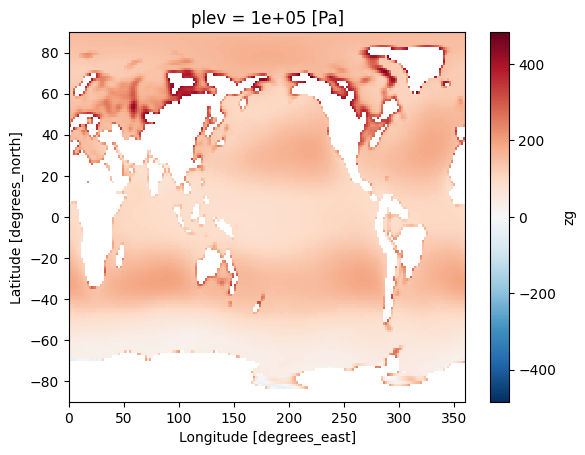

In [67]:
ds.zg.isel(plev=0).mean('time').plot()

In [ ]:
import asyncio
import icechunk as ic
from onepassword.client import Client, DesktopAuth
import xarray as xr

async def get_osn_storage() -> ic.Storage:
    client = await Client.authenticate(
        auth=DesktopAuth(account_name="MHLAA3V7UJCOBFLR5DBUI5SRCY"),
        integration_name="Jupyter icechunk",
        integration_version="v1.0.0",
    )
    
    key_id = await client.secrets.resolve("op://Work/z6baienaiyhiexztlbbonbeaka/Read-Write/Access Key ID")
    secret = await client.secrets.resolve("op://Work/z6baienaiyhiexztlbbonbeaka/Read-Write/Secret Access Key")

    return ic.s3_storage(
        bucket='leap-m2lines-test',
        prefix=f'cmip6_virtualizarr/{cmip_id}/',
        endpoint_url='https://nyu1.osn.mghpcc.org',
        region='us-east-1',          # required even for non-AWS
        access_key_id=key_id,
        secret_access_key=secret,
        force_path_style=True,       # needed for Ceph
    )

osn_storage = await get_osn_storage()

url_prefix = 'https://dap.ceda.ac.uk/'

repo = ic.Repository.open(
    storage=osn_storage,
    authorize_virtual_chunk_access={
        url_prefix: None 
    }
)
session = repo.readonly_session('main')
ds_osn = xr.open_zarr(session.store)

/Users/juliusbusecke/Code/cmip7-virtualization/.venv/lib/python3.12/site-packages/zarr/codecs/numcodecs/_codecs.py:139: ZarrUserWarning: Numcodecs codecs are not in the Zarr version 3 specification and may not be supported by other zarr implementations.
  super().__init__(**codec_config)


In [15]:
ds_osn

<xarray.Dataset> Size: 982MB
Dimensions:    (time: 1110, bnds: 2, lon: 192, lat: 144, plev: 8)
Coordinates:
  * time       (time) object 9kB 1991-06-01 12:00:00 ... 1994-06-30 12:00:00
  * lon        (lon) float64 2kB 0.9375 2.812 4.688 6.562 ... 355.3 357.2 359.1
  * lat        (lat) float64 1kB -89.38 -88.12 -86.88 ... 86.88 88.12 89.38
  * plev       (plev) float64 64B 1e+05 8.5e+04 7e+04 ... 1e+04 5e+03 1e+03
Dimensions without coordinates: bnds
Data variables:
    time_bnds  (time, bnds) object 18kB dask.array<chunksize=(1, 2), meta=np.ndarray>
    lon_bnds   (lon, bnds) float64 3kB dask.array<chunksize=(192, 2), meta=np.ndarray>
    lat_bnds   (lat, bnds) float64 2kB dask.array<chunksize=(144, 2), meta=np.ndarray>
    zg         (time, plev, lat, lon) float32 982MB dask.array<chunksize=(1, 8, 144, 192), meta=np.ndarray>
Attributes: (12/47)
    Conventions:            CF-1.7 CMIP-6.2
    activity_id:            VolMIP
    branch_method:          standard
    branch_time_in_child:   50910.0
    branch_time_in_parent:  432870.0
    creation_date:          2023-08-04T00:36:24Z
    ...                     ...
    tracking_id:            hdl:21.14100/731ffca5-707a-4378-a65e-bf801b7787c4
    variable_id:            zg
    variable_name:          zg
    variant_label:          r9i1p1f2
    license:                CMIP6 model data produced by the Natural Environm...
    cmor_version:           3.7.1

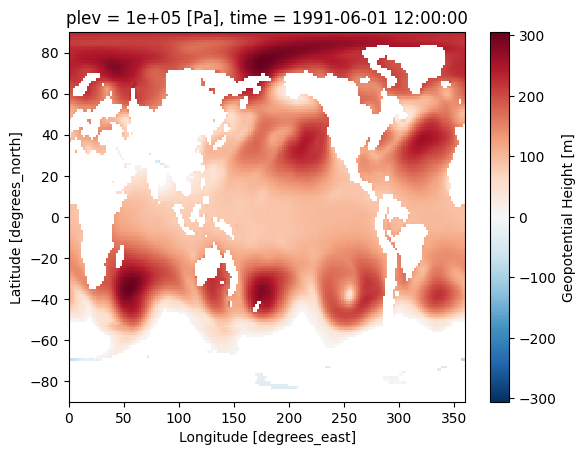

In [17]:
ds_osn.zg.isel(plev=0, time=0).plot()

## Now lets populate the playground as a mirror of ceda

In [ ]:
def add_icechunk_to_item(collection_id: str, item_id: str) -> dict:
    """
    Fetch item, add icechunk store as an alternate entry under reference_file, PUT back.
    Returns the updated item.
    """
    r = httpx.get(f"{LOCAL_STAC}/collections/{collection_id}/items/{item_id}", timeout=30)
    r.raise_for_status()
    item = r.json()

    ref = item["assets"].get("reference_file")
    if ref is None:
        raise ValueError(f"Item {item_id} has no reference_file asset")

    if "alternate" not in ref:
        ref["alternate"] = {}

    if ICECHUNK_NODE in ref["alternate"]:
        return item  # already done

    ref["alternate"][ICECHUNK_NODE] = add_icechunk_alternate(
        item_id=item_id,
        node_name=ICECHUNK_NODE,
        href=f"{ICECHUNK_BASE}/{item_id}/icechunk",
    )

    r = httpx.put(
        f"{LOCAL_STAC}/collections/{collection_id}/items/{item_id}",
        json=item,
        timeout=30,
    )
    r.raise_for_status()
    return r.json()


updated = []
for item in items_with_ref:
    result = add_icechunk_to_item(item["collection"], item["id"])
    updated.append(result)

print(f"✓ Added icechunk alternate to reference_file for {len(updated)} items")

## Questions

- Where is the schema defined? How can I propose changes
- Why is the refernce an asset level entry? 
- Related relations for virtual datasets? (how are these kept in sync?) for now ignoring these (we will produce one reference per node max)
- reference files need to declare which assets were used to build them! Are the 'data_000XXX' references immutable?
- How would we subscribe to the publication? Are files published as batch or on file at a time?